# Week 11: Learned Query Pooler vs Heuristic - Fair Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniJani/reposynth/blob/Research/research/Week11_Learned_vs_Heuristic_Evaluation.ipynb)

This notebook provides a **fair evaluation** comparing the Learned Query Pooler against the Heuristic TopicInferrer.

## Key Differences from Week 10:
- **Train/Test Split**: Training and test data are completely separate
- **New Test Questions**: Test examples different from Week 10 training data
- **Real CCE Pipeline**: Integrates with actual CCE spike detection
- **End-to-End Evaluation**: Measures impact on actual retrieval quality

## Experiment Design:
1. **Training Set**: 70% of benchmark examples
2. **Test Set**: 30% held-out examples (never seen during training)
3. **Metrics**: P@K, R@K, NDCG@K, MRR, MAP on test set only

## 1. Setup & Installation

In [1]:
# Install required packages
!pip install -q sentence-transformers torch numpy matplotlib seaborn pandas scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import re
import random
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any, Union
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

# Check if running in Colab
try:
    from google.colab import files
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Running in Google Colab
Using device: cuda


## 2. Define All Module Components

Self-contained definitions for Colab compatibility.

In [3]:
# ============================================================================
# CONFUSED TOKEN ENCODER
# ============================================================================

class ConfusedTokenEncoder(nn.Module):
    def __init__(self, embed_dim=384, model_name='all-MiniLM-L6-v2', dropout=0.1, max_tokens=20):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_tokens = max_tokens
        self._encoder = SentenceTransformer(model_name)
        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None
        self.prob_transform = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.dropout = nn.Dropout(dropout)
        self.output_norm = nn.LayerNorm(embed_dim)

    def forward(self, tokens, probabilities=None, return_weights=False):
        if not tokens:
            empty = torch.zeros(1, self.embed_dim, device=device)
            return (empty, torch.ones(1, device=device)) if return_weights else empty
        tokens = tokens[:self.max_tokens]
        with torch.no_grad():
            raw_emb = self._encoder.encode(tokens, convert_to_tensor=True, show_progress_bar=False)
        embeddings = raw_emb.to(device)
        if self._projection:
            embeddings = self._projection(embeddings)
        embeddings = self.dropout(embeddings)
        if probabilities:
            probs = probabilities[:len(tokens)]
            prob_tensor = torch.tensor(probs, dtype=torch.float32, device=device).unsqueeze(-1)
            weights = self.prob_transform(prob_tensor).squeeze(-1)
            embeddings = embeddings * weights.unsqueeze(-1)
        else:
            weights = torch.ones(len(tokens), device=device)
        embeddings = self.output_norm(embeddings)
        return (embeddings, weights) if return_weights else embeddings

print("ConfusedTokenEncoder defined")

ConfusedTokenEncoder defined


In [4]:
# ============================================================================
# CONTEXT ENCODER
# ============================================================================

class ContextEncoder(nn.Module):
    def __init__(self, embed_dim=384, model_name='all-MiniLM-L6-v2', dropout=0.1, chunk_size=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.chunk_size = chunk_size
        self._encoder = SentenceTransformer(model_name)
        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None
        self.dropout = nn.Dropout(dropout)
        self.type_embeddings = nn.Embedding(2, embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)

    def forward(self, query, context, return_separate=False):
        texts, types = [], []
        if query:
            texts.append(query)
            types.append(0)
        for i in range(0, len(context), self.chunk_size):
            chunk = context[i:i+self.chunk_size].strip()
            if chunk:
                texts.append(chunk)
                types.append(1)
        if not texts:
            texts, types = [""], [1]
        with torch.no_grad():
            raw_emb = self._encoder.encode(texts, convert_to_tensor=True, show_progress_bar=False)
        embeddings = raw_emb.to(device)
        if self._projection:
            embeddings = self._projection(embeddings)
        type_tensor = torch.tensor(types, dtype=torch.long, device=device)
        embeddings = embeddings + self.type_embeddings(type_tensor)
        embeddings = self.dropout(embeddings)
        embeddings = self.output_norm(embeddings)
        if return_separate and query:
            return embeddings[0:1], embeddings[1:] if len(embeddings) > 1 else embeddings
        return embeddings

print("ContextEncoder defined")

ContextEncoder defined


In [5]:
# ============================================================================
# LEARNED QUERY POOLER
# ============================================================================

class LearnedQueryPooler(nn.Module):
    def __init__(self, embed_dim=384, num_query_vectors=4, num_heads=4, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.query_vectors = nn.Parameter(torch.randn(num_query_vectors, embed_dim) * 0.02)
        self.token_cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.context_cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.fusion = nn.Sequential(nn.Linear(embed_dim * 2, embed_dim), nn.GELU(), nn.Dropout(dropout))
        self.output_projection = nn.Linear(embed_dim, embed_dim)
        self.token_norm = nn.LayerNorm(embed_dim)
        self.context_norm = nn.LayerNorm(embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_embs, context_embs, return_attention_weights=False):
        if token_embs.dim() == 2:
            token_embs = token_embs.unsqueeze(0)
        if context_embs.dim() == 2:
            context_embs = context_embs.unsqueeze(0)
        batch_size = token_embs.shape[0]
        queries = self.query_vectors.unsqueeze(0).expand(batch_size, -1, -1)
        token_attended, token_attn = self.token_cross_attn(queries, token_embs, token_embs)
        token_attended = self.token_norm(token_attended)
        context_attended, context_attn = self.context_cross_attn(queries, context_embs, context_embs)
        context_attended = self.context_norm(context_attended)
        fused = self.fusion(torch.cat([token_attended, context_attended], dim=-1))
        pooled = fused.mean(dim=1)
        output = self.output_norm(self.dropout(self.output_projection(pooled)))
        if batch_size == 1:
            output = output.squeeze(0)
        attn = {'token_attention': token_attn, 'context_attention': context_attn} if return_attention_weights else None
        return output, attn

print("LearnedQueryPooler defined")

LearnedQueryPooler defined


In [6]:
# ============================================================================
# FILE SCORER & CACHE
# ============================================================================

class LearnedFileScorer(nn.Module):
    def __init__(self, embed_dim=384, scoring_method="bilinear", dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.scoring_method = scoring_method
        if scoring_method == "bilinear":
            self.bilinear = nn.Bilinear(embed_dim, embed_dim, 1, bias=True)
        self.query_projection = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_emb, file_embs, return_probabilities=False):
        if query_emb.dim() == 1:
            query_emb = query_emb.unsqueeze(0)
        if file_embs.dim() == 2:
            file_embs = file_embs.unsqueeze(0)
        batch_size, num_files = query_emb.shape[0], file_embs.shape[1]
        query_emb = self.dropout(self.query_projection(query_emb))
        if self.scoring_method == "bilinear":
            query_exp = query_emb.unsqueeze(1).expand(-1, num_files, -1).reshape(-1, self.embed_dim)
            file_flat = file_embs.reshape(-1, self.embed_dim)
            scores = self.bilinear(query_exp, file_flat).reshape(batch_size, num_files)
        else:  # cosine
            query_norm = F.normalize(query_emb, p=2, dim=-1)
            file_norm = F.normalize(file_embs, p=2, dim=-1)
            scores = torch.bmm(query_norm.unsqueeze(1), file_norm.transpose(1, 2)).squeeze(1)
        scores = scores.squeeze(0) if batch_size == 1 else scores
        if return_probabilities:
            return scores, F.softmax(scores, dim=-1)
        return scores


class FileEmbeddingCache:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self._encoder = SentenceTransformer(model_name)
        self._cache = {}
        self._file_paths = []

    def _path_to_text(self, path):
        parts = re.split(r'[/\\._]', path.lower())
        return ' '.join(p for p in parts if len(p) >= 2)

    def build_cache(self, file_paths):
        self._file_paths = file_paths
        texts = [self._path_to_text(p) for p in file_paths]
        embeddings = self._encoder.encode(texts, show_progress_bar=False)
        return torch.tensor(embeddings, dtype=torch.float32, device=device)

print("LearnedFileScorer and FileEmbeddingCache defined")

LearnedFileScorer and FileEmbeddingCache defined


In [7]:
# ============================================================================
# LEARNED QUERY MODULE (MAIN)
# ============================================================================

@dataclass
class LearnedQueryResult:
    query_embedding: torch.Tensor
    matched_files: List[str]
    file_scores: Dict[str, float]
    confidence: float
    token_attention: Optional[torch.Tensor] = None
    context_attention: Optional[torch.Tensor] = None


class LearnedQueryModule(nn.Module):
    def __init__(self, embed_dim=384, num_query_vectors=4, num_heads=4, dropout=0.1,
                 model_name='all-MiniLM-L6-v2', scoring_method="bilinear",
                 score_threshold=0.1, top_k=3):
        super().__init__()
        self.embed_dim = embed_dim
        self.score_threshold = score_threshold
        self.top_k = top_k
        self.token_encoder = ConfusedTokenEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.context_encoder = ContextEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.pooler = LearnedQueryPooler(embed_dim=embed_dim, num_query_vectors=num_query_vectors, num_heads=num_heads, dropout=dropout)
        self.scorer = LearnedFileScorer(embed_dim=embed_dim, scoring_method=scoring_method, dropout=dropout)
        self.file_cache = FileEmbeddingCache(model_name=model_name)
        self._file_paths = []
        self._file_embeddings = None

    def set_available_files(self, file_paths):
        self._file_paths = file_paths
        self._file_embeddings = self.file_cache.build_cache(file_paths)

    def forward(self, confused_tokens, confused_probs=None, original_query="", generated_context="", return_attention=False):
        if not confused_tokens:
            return LearnedQueryResult(torch.zeros(self.embed_dim, device=device), [], {}, 0.0)
        token_embs, _ = self.token_encoder(confused_tokens, confused_probs, return_weights=True)
        context_embs = self.context_encoder(original_query, generated_context)
        query_emb, attn = self.pooler(token_embs, context_embs, return_attention_weights=True)
        file_scores = {}
        if self._file_embeddings is not None:
            _, probs = self.scorer(query_emb, self._file_embeddings, return_probabilities=True)
            scores_np = probs.detach().cpu().numpy()
            for i, path in enumerate(self._file_paths):
                file_scores[path] = float(scores_np[i])
        sorted_files = sorted(file_scores.items(), key=lambda x: -x[1])
        matched_files = [f for f, s in sorted_files[:self.top_k] if s >= self.score_threshold]
        # Confidence from attention entropy
        confidence = 0.5
        if attn and attn.get('token_attention') is not None:
            with torch.no_grad():
                a = attn['token_attention'].mean(dim=(0,1)).clamp(min=1e-8)
                entropy = -(a * torch.log(a)).sum()
                max_ent = np.log(len(a)) if len(a) > 1 else 1.0
                confidence = float(max(0.0, min(1.0, 1.0 - entropy.item() / max_ent))) if max_ent > 0 else 0.5
        result = LearnedQueryResult(query_emb, matched_files, file_scores, confidence)
        if return_attention and attn:
            result.token_attention = attn.get('token_attention')
            result.context_attention = attn.get('context_attention')
        return result

print("LearnedQueryModule defined")

LearnedQueryModule defined


In [8]:
# ============================================================================
# LOSS FUNCTION
# ============================================================================

class QueryPoolerLoss(nn.Module):
    def __init__(self, ranking_margin=0.5, ranking_weight=1.0, contrastive_weight=0.5, attention_reg_weight=0.1, temperature=0.07):
        super().__init__()
        self.ranking_margin = ranking_margin
        self.ranking_weight = ranking_weight
        self.contrastive_weight = contrastive_weight
        self.attention_reg_weight = attention_reg_weight
        self.temperature = temperature

    def forward(self, query_emb, file_embs, file_scores, relevant_indices, attention_weights=None):
        if query_emb.dim() == 1:
            query_emb = query_emb.unsqueeze(0)
        if file_embs.dim() == 2:
            file_embs = file_embs.unsqueeze(0)
        if file_scores.dim() == 1:
            file_scores = file_scores.unsqueeze(0)
        batch_size, num_files = file_scores.shape
        relevance_mask = torch.zeros(batch_size, num_files, device=query_emb.device)
        for idx in relevant_indices:
            if idx < num_files:
                relevance_mask[:, idx] = 1.0
        pos_mask, neg_mask = relevance_mask.bool(), ~relevance_mask.bool()
        ranking_loss = torch.tensor(0.0, device=query_emb.device)
        if pos_mask.any() and neg_mask.any():
            for b in range(batch_size):
                pos_scores = file_scores[b, pos_mask[b]]
                neg_scores = file_scores[b, neg_mask[b]]
                if len(pos_scores) > 0 and len(neg_scores) > 0:
                    for ps in pos_scores:
                        ranking_loss = ranking_loss + F.relu(self.ranking_margin + neg_scores - ps).mean()
        # Contrastive
        query_norm = F.normalize(query_emb, p=2, dim=-1)
        file_norm = F.normalize(file_embs, p=2, dim=-1)
        similarities = torch.bmm(query_norm.unsqueeze(1), file_norm.transpose(1, 2)).squeeze(1)
        logits = similarities / self.temperature
        pos_logits = logits.clone()
        pos_logits[~pos_mask] = float('-inf')
        contrastive_loss = -(torch.logsumexp(pos_logits, dim=-1) - torch.logsumexp(logits, dim=-1)).mean() if pos_mask.any() else torch.tensor(0.0, device=query_emb.device)
        # Attention reg
        attention_loss = torch.tensor(0.0, device=query_emb.device)
        if attention_weights and self.attention_reg_weight > 0:
            for attn in attention_weights.values():
                if attn is not None:
                    if attn.dim() == 2:
                        attn = attn.unsqueeze(0)
                    attn_clamped = attn.clamp(min=1e-8)
                    entropy = -(attn_clamped * torch.log(attn_clamped)).sum(dim=-1)
                    attention_loss = attention_loss + entropy.mean()
        total = self.ranking_weight * ranking_loss + self.contrastive_weight * contrastive_loss + self.attention_reg_weight * attention_loss
        return total, {'total': total.item(), 'ranking': ranking_loss.item(), 'contrastive': contrastive_loss.item()}

print("QueryPoolerLoss defined")

QueryPoolerLoss defined


In [9]:
# ============================================================================
# HEURISTIC BASELINE (TopicInferrer Simulation)
# ============================================================================

class HeuristicTopicInferrer:
    """Simulates the heuristic TopicInferrer using keyword matching."""

    def __init__(self, file_paths: List[str]):
        self.file_paths = file_paths
        self._file_keywords = {}
        for path in file_paths:
            parts = re.split(r'[/\\._]', path.lower())
            self._file_keywords[path] = set(p for p in parts if len(p) >= 2)

    def infer(self, confused_tokens: List[str], query: str = "", k: int = 3) -> Dict:
        """Match files using keyword overlap."""
        query_keywords = set(t.lower() for t in confused_tokens)
        query_words = set(w.lower() for w in re.findall(r'\w+', query) if len(w) >= 3)
        query_keywords.update(query_words)

        scores = {}
        for path, file_kw in self._file_keywords.items():
            overlap = len(query_keywords & file_kw)
            exact_bonus = sum(1 for t in confused_tokens if t.lower() in path.lower())
            scores[path] = overlap + exact_bonus * 0.5

        sorted_files = sorted(scores.items(), key=lambda x: -x[1])
        matched_files = [f for f, s in sorted_files[:k]]

        return {
            'matched_files': matched_files,
            'file_scores': scores,
            'confidence': 0.5,  # Heuristic has no learned confidence
        }

print("HeuristicTopicInferrer defined")

HeuristicTopicInferrer defined


## 3. Evaluation Metrics

In [10]:
# ============================================================================
# RETRIEVAL METRICS
# ============================================================================

def precision_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    if k == 0:
        return 0.0
    predicted_k = predicted[:k]
    return len(set(predicted_k) & set(relevant)) / k

def recall_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    if not relevant:
        return 0.0
    return len(set(predicted[:k]) & set(relevant)) / len(relevant)

def ndcg_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    if not relevant or k == 0:
        return 0.0
    relevant_set = set(relevant)
    dcg = sum(1.0 / np.log2(i + 2) for i, p in enumerate(predicted[:k]) if p in relevant_set)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def mrr(predicted: List[str], relevant: List[str]) -> float:
    relevant_set = set(relevant)
    for i, p in enumerate(predicted):
        if p in relevant_set:
            return 1.0 / (i + 1)
    return 0.0

def average_precision(predicted: List[str], relevant: List[str]) -> float:
    if not relevant:
        return 0.0
    relevant_set = set(relevant)
    hits, sum_prec = 0, 0.0
    for i, p in enumerate(predicted):
        if p in relevant_set:
            hits += 1
            sum_prec += hits / (i + 1)
    return sum_prec / len(relevant)

def compute_metrics(predicted: List[str], relevant: List[str], k: int = 3) -> Dict[str, float]:
    return {
        f'P@{k}': precision_at_k(predicted, relevant, k),
        f'R@{k}': recall_at_k(predicted, relevant, k),
        f'NDCG@{k}': ndcg_at_k(predicted, relevant, k),
        'MRR': mrr(predicted, relevant),
        'MAP': average_precision(predicted, relevant),
    }

print("Retrieval metrics defined")

Retrieval metrics defined


## 4. Load Training Data

You can either:
- **Option A**: Upload your own data files (recommended for larger datasets)
- **Option B**: Use the built-in demo data (30 samples - limited)

### Data Format

**training_samples.json:**
```json
[
    {
        "sample_id": "auth_001",
        "confused_tokens": ["token", "jwt", "auth"],
        "confused_probs": [0.3, 0.25, 0.2],
        "original_query": "How does authentication work?",
        "generated_context": "Authentication uses...",
        "relevant_files": ["auth_service.py"],
        "difficulty": "easy"
    }
]
```

**file_list.json:**
```json
["auth_service.py", "api_router.py", ...]
```

In [11]:
# ============================================================================
# OPTION A: UPLOAD YOUR OWN DATA (Recommended for 100+ samples)
# ============================================================================

uploaded_train_data = None
uploaded_test_data = None
uploaded_file_list = None
USE_UPLOADED_DATA = False

def upload_training_data():
    """Upload training samples JSON file."""
    global uploaded_train_data
    if IN_COLAB:
        print("Upload your training_samples.json (or training_samples_large.json):")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            uploaded_train_data = json.loads(uploaded[filename].decode('utf-8'))
            print(f"Loaded {len(uploaded_train_data)} training samples")
            return uploaded_train_data
    else:
        print("Running locally. Load manually:")
        print("  uploaded_train_data = json.load(open('training_samples_large.json'))")
    return None

def upload_test_data():
    """Upload test samples JSON file."""
    global uploaded_test_data
    if IN_COLAB:
        print("\nUpload your test_samples.json:")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            uploaded_test_data = json.loads(uploaded[filename].decode('utf-8'))
            print(f"Loaded {len(uploaded_test_data)} test samples")
            return uploaded_test_data
    else:
        print("Running locally. Load manually:")
        print("  uploaded_test_data = json.load(open('test_samples.json'))")
    return None

def upload_file_list():
    """Upload file list JSON."""
    global uploaded_file_list
    if IN_COLAB:
        print("\nUpload your file_list.json (or file_list_large.json):")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            uploaded_file_list = json.loads(uploaded[filename].decode('utf-8'))
            print(f"Loaded {len(uploaded_file_list)} files")
            return uploaded_file_list
    else:
        print("Running locally. Load manually:")
        print("  uploaded_file_list = json.load(open('file_list_large.json'))")
    return None

# Run uploads
print("=" * 60)
print("OPTION A: Upload Your Data Files")
print("=" * 60)
print("(Skip this cell and run the next one to use built-in demo data)\n")

uploaded_train_data = upload_training_data()
uploaded_test_data = upload_test_data()
uploaded_file_list = upload_file_list()

if uploaded_train_data and uploaded_file_list:
    USE_UPLOADED_DATA = True
    print(f"\n✓ Using uploaded data: {len(uploaded_train_data)} train samples")
    if uploaded_test_data:
        print(f"✓ Test samples: {len(uploaded_test_data)}")
    else:
        print("✓ Will auto-split training data 80/20")
else:
    print("\n⚠ No data uploaded. Will use built-in demo data (30 samples).")

OPTION A: Upload Your Data Files
(Skip this cell and run the next one to use built-in demo data)

Upload your training_samples.json (or training_samples_large.json):


Saving training_samples_large.json to training_samples_large.json
Loaded 141 training samples

Upload your test_samples.json:


Saving test_samples.json to test_samples.json
Loaded 36 test samples

Upload your file_list.json (or file_list_large.json):


Saving file_list_large.json to file_list_large.json
Loaded 55 files

✓ Using uploaded data: 141 train samples
✓ Test samples: 36


In [12]:
@dataclass
class BenchmarkSample:
    """A benchmark sample for evaluation."""
    sample_id: str
    confused_tokens: List[str]
    confused_probs: List[float]
    original_query: str
    generated_context: str
    relevant_files: List[str]
    difficulty: str = "medium"

print("BenchmarkSample defined")

BenchmarkSample defined


### Option B: Built-in Demo Data (Fallback)

The cell below defines 30 built-in samples as a fallback if you don't upload data.

In [13]:
# ============================================================================
# EXPANDED BENCHMARK DATASET
# ============================================================================
# This contains MORE examples than Week 10 training data
# We'll split into train (70%) and test (30%)

# File list (same as before)
FILE_LIST = [
    "api_router.py",
    "auth_service.py",
    "cache_service.py",
    "database_service.py",
    "event_system.py",
    "fastapi/background.py",
    "fastapi/dependencies/utils.py",
    "fastapi/params.py",
    "fastapi/routing.py",
    "requests/adapters.py",
    "requests/api.py",
    "requests/auth.py",
    "requests/cookies.py",
    "requests/models.py",
    "requests/sessions.py",
    "src/flask/app.py",
    "src/flask/blueprints.py",
    "src/flask/config.py",
    "src/flask/ctx.py",
    "src/flask/globals.py",
    "src/flask/helpers.py",
    "src/flask/scaffold.py",
]

# Expanded benchmark with 30 samples (more than Week 10's 17)
FULL_BENCHMARK = [
    # Authentication domain (10 samples)
    BenchmarkSample("auth_001", ["TokenManager", "generate", "token", "signature"], [0.25, 0.22, 0.18, 0.15], "How does TokenManager generate tokens?", "TokenManager generates tokens by", ["auth_service.py"], "easy"),
    BenchmarkSample("auth_002", ["jwt", "encode", "payload", "secret"], [0.28, 0.24, 0.20, 0.15], "How are JWT tokens encoded?", "JWT tokens are encoded using", ["auth_service.py"], "easy"),
    BenchmarkSample("auth_003", ["authenticate", "user", "password", "hash"], [0.26, 0.23, 0.19, 0.16], "How does user authentication work?", "User authentication involves", ["auth_service.py"], "medium"),
    BenchmarkSample("auth_004", ["session", "cookie", "secure", "httponly"], [0.27, 0.23, 0.18, 0.14], "How are sessions managed with cookies?", "Sessions use cookies that are", ["requests/cookies.py", "requests/sessions.py"], "medium"),
    BenchmarkSample("auth_005", ["OAuth", "token", "refresh", "expire"], [0.25, 0.22, 0.20, 0.17], "How does OAuth token refresh work?", "OAuth tokens can be refreshed by", ["auth_service.py", "requests/auth.py"], "hard"),
    BenchmarkSample("auth_006", ["BasicAuth", "header", "base64", "credentials"], [0.26, 0.24, 0.19, 0.15], "How is BasicAuth implemented?", "BasicAuth sends credentials as", ["requests/auth.py"], "easy"),
    BenchmarkSample("auth_007", ["permission", "role", "access", "check"], [0.24, 0.22, 0.20, 0.18], "How are permissions checked?", "Permissions are verified by", ["auth_service.py"], "medium"),
    BenchmarkSample("auth_008", ["login", "validate", "credentials", "store"], [0.27, 0.23, 0.18, 0.14], "How does the login flow work?", "Login validates credentials and", ["auth_service.py"], "easy"),
    BenchmarkSample("auth_009", ["logout", "session", "invalidate", "clear"], [0.25, 0.23, 0.20, 0.16], "How does logout clear sessions?", "Logout invalidates the session by", ["requests/sessions.py", "auth_service.py"], "medium"),
    BenchmarkSample("auth_010", ["token", "verify", "signature", "decode"], [0.26, 0.24, 0.19, 0.15], "How are tokens verified?", "Tokens are verified by checking", ["auth_service.py"], "easy"),

    # API/Routing domain (8 samples)
    BenchmarkSample("api_001", ["router", "endpoint", "path", "method"], [0.27, 0.24, 0.19, 0.14], "How are API routes defined?", "API routes are defined using", ["api_router.py", "fastapi/routing.py"], "easy"),
    BenchmarkSample("api_002", ["dependency", "inject", "Depends", "param"], [0.26, 0.23, 0.19, 0.16], "How does dependency injection work?", "Dependencies are injected via", ["fastapi/dependencies/utils.py", "fastapi/params.py"], "medium"),
    BenchmarkSample("api_003", ["middleware", "request", "response", "intercept"], [0.25, 0.23, 0.20, 0.16], "How does middleware intercept requests?", "Middleware intercepts by", ["fastapi/routing.py"], "medium"),
    BenchmarkSample("api_004", ["background", "task", "async", "schedule"], [0.28, 0.24, 0.18, 0.14], "How are background tasks scheduled?", "Background tasks are scheduled using", ["fastapi/background.py"], "easy"),
    BenchmarkSample("api_005", ["blueprint", "register", "prefix", "url"], [0.26, 0.23, 0.19, 0.16], "How do Flask blueprints work?", "Blueprints organize routes by", ["src/flask/blueprints.py", "src/flask/app.py"], "medium"),
    BenchmarkSample("api_006", ["request", "context", "global", "thread"], [0.25, 0.23, 0.20, 0.16], "How does Flask request context work?", "Request context is managed via", ["src/flask/ctx.py", "src/flask/globals.py"], "hard"),
    BenchmarkSample("api_007", ["adapter", "mount", "session", "transport"], [0.27, 0.24, 0.18, 0.15], "How do request adapters work?", "Adapters handle transport by", ["requests/adapters.py", "requests/sessions.py"], "hard"),
    BenchmarkSample("api_008", ["response", "model", "serialize", "json"], [0.26, 0.23, 0.19, 0.16], "How are responses serialized?", "Responses are serialized using", ["requests/models.py"], "easy"),

    # Caching domain (4 samples)
    BenchmarkSample("cache_001", ["cache", "get", "set", "expire"], [0.28, 0.24, 0.18, 0.14], "How does caching work?", "The cache stores values with", ["cache_service.py"], "easy"),
    BenchmarkSample("cache_002", ["invalidate", "cache", "key", "delete"], [0.26, 0.23, 0.19, 0.16], "How is cache invalidated?", "Cache is invalidated by", ["cache_service.py"], "easy"),
    BenchmarkSample("cache_003", ["memoize", "decorator", "function", "cache"], [0.25, 0.23, 0.20, 0.16], "How does memoization work?", "Memoization caches function results by", ["cache_service.py"], "medium"),
    BenchmarkSample("cache_004", ["ttl", "expire", "timeout", "refresh"], [0.27, 0.24, 0.18, 0.15], "How does TTL-based expiration work?", "TTL determines when cached items", ["cache_service.py"], "medium"),

    # Database domain (4 samples)
    BenchmarkSample("db_001", ["connection", "pool", "database", "query"], [0.26, 0.23, 0.19, 0.16], "How does connection pooling work?", "Connection pools manage", ["database_service.py"], "medium"),
    BenchmarkSample("db_002", ["transaction", "commit", "rollback", "atomic"], [0.28, 0.24, 0.18, 0.14], "How do transactions work?", "Transactions ensure atomicity by", ["database_service.py"], "medium"),
    BenchmarkSample("db_003", ["query", "execute", "cursor", "result"], [0.25, 0.23, 0.20, 0.16], "How are queries executed?", "Queries are executed using", ["database_service.py"], "easy"),
    BenchmarkSample("db_004", ["migrate", "schema", "alter", "version"], [0.27, 0.24, 0.18, 0.15], "How do database migrations work?", "Migrations alter the schema by", ["database_service.py"], "hard"),

    # Events domain (4 samples)
    BenchmarkSample("event_001", ["event", "emit", "listener", "subscribe"], [0.26, 0.23, 0.19, 0.16], "How does the event system work?", "Events are emitted and", ["event_system.py"], "easy"),
    BenchmarkSample("event_002", ["handler", "callback", "register", "dispatch"], [0.25, 0.23, 0.20, 0.16], "How are event handlers registered?", "Handlers are registered by", ["event_system.py"], "easy"),
    BenchmarkSample("event_003", ["async", "event", "await", "queue"], [0.28, 0.24, 0.18, 0.14], "How do async events work?", "Async events are processed via", ["event_system.py"], "medium"),
    BenchmarkSample("event_004", ["broadcast", "channel", "subscriber", "publish"], [0.27, 0.24, 0.18, 0.15], "How does event broadcasting work?", "Broadcasting sends events to", ["event_system.py"], "hard"),
]

print(f"Total benchmark samples: {len(FULL_BENCHMARK)}")
print(f"Total files: {len(FILE_LIST)}")

Total benchmark samples: 30
Total files: 22


In [14]:
# ============================================================================
# PREPARE DATA (from upload or built-in)
# ============================================================================

if USE_UPLOADED_DATA and uploaded_train_data and uploaded_file_list:
    print("=" * 60)
    print("USING UPLOADED DATA")
    print("=" * 60)

    FILE_LIST = uploaded_file_list

    # Convert uploaded JSON to BenchmarkSample objects
    def json_to_sample(item):
        return BenchmarkSample(
            sample_id=item.get('sample_id', ''),
            confused_tokens=item.get('confused_tokens', []),
            confused_probs=item.get('confused_probs', [0.25] * len(item.get('confused_tokens', []))),
            original_query=item.get('original_query', ''),
            generated_context=item.get('generated_context', ''),
            relevant_files=[f for f in item.get('relevant_files', []) if f in FILE_LIST],
            difficulty=item.get('difficulty', 'medium'),
        )

    # Filter samples that have valid relevant files
    all_uploaded_samples = [json_to_sample(item) for item in uploaded_train_data]
    all_uploaded_samples = [s for s in all_uploaded_samples if s.relevant_files and s.confused_tokens]

    if uploaded_test_data:
        # Use separate test file
        train_samples = all_uploaded_samples
        test_samples_raw = [json_to_sample(item) for item in uploaded_test_data]
        test_samples = [s for s in test_samples_raw if s.relevant_files and s.confused_tokens]
    else:
        # Auto-split 80/20
        difficulties = [s.difficulty for s in all_uploaded_samples]
        train_samples, test_samples = train_test_split(
            all_uploaded_samples,
            test_size=0.2,
            random_state=SEED,
            stratify=difficulties if len(set(difficulties)) > 1 else None
        )

    print(f"Training samples: {len(train_samples)}")
    print(f"Test samples: {len(test_samples)}")
    print(f"File list: {len(FILE_LIST)} files")

else:
    print("=" * 60)
    print("USING BUILT-IN DEMO DATA (30 samples)")
    print("=" * 60)
    print("For better results, upload larger dataset from Week11_Data_Collection.ipynb")

    # Use hardcoded data from cell-16
    difficulties = [s.difficulty for s in FULL_BENCHMARK]
    train_samples, test_samples = train_test_split(
        FULL_BENCHMARK,
        test_size=0.3,
        random_state=SEED,
        stratify=difficulties
    )

    print(f"Training samples: {len(train_samples)}")
    print(f"Test samples: {len(test_samples)}")

print(f"\nTraining IDs: {[s.sample_id for s in train_samples[:5]]}...")
print(f"Test IDs (HELD OUT): {[s.sample_id for s in test_samples[:5]]}...")

USING UPLOADED DATA
Training samples: 141
Test samples: 36
File list: 55 files

Training IDs: ['http_125', 'auth_113', 'events_096', 'flask_055', 'api_172']...
Test IDs (HELD OUT): ['http_035', 'api_036', 'auth_097', 'auth_094', 'http_119']...


## 5. Train Learned Model on Training Set Only

In [15]:
# ============================================================================
# INITIALIZE LEARNED MODEL
# ============================================================================

learned_module = LearnedQueryModule(
    embed_dim=384,
    num_query_vectors=4,
    num_heads=4,
    scoring_method="bilinear",
    score_threshold=0.1,
    top_k=3,
).to(device)

learned_module.set_available_files(FILE_LIST)
print(f"Learned module initialized with {len(FILE_LIST)} files")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Learned module initialized with 55 files


Training on 141 samples for 30 epochs...
(Test samples are HELD OUT - not seen during training)

Epoch  5: loss = 0.4970
Epoch 10: loss = 0.3121
Epoch 15: loss = 0.2725
Epoch 20: loss = 0.2378
Epoch 25: loss = 0.2239
Epoch 30: loss = 0.2117


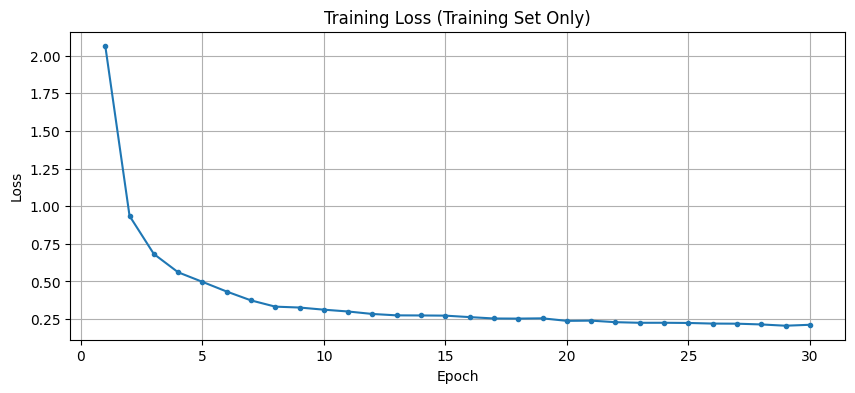

In [16]:
# ============================================================================
# TRAIN ON TRAINING SET ONLY
# ============================================================================

file_to_idx = {f: i for i, f in enumerate(FILE_LIST)}
loss_fn = QueryPoolerLoss(ranking_weight=1.0, contrastive_weight=0.5, attention_reg_weight=0.1)
optimizer = torch.optim.AdamW(learned_module.parameters(), lr=1e-4, weight_decay=0.01)

NUM_EPOCHS = 30
history = []

print(f"Training on {len(train_samples)} samples for {NUM_EPOCHS} epochs...")
print("(Test samples are HELD OUT - not seen during training)\n")

for epoch in range(NUM_EPOCHS):
    learned_module.train()
    epoch_loss = 0.0

    for sample in train_samples:
        optimizer.zero_grad()

        result = learned_module(
            confused_tokens=sample.confused_tokens,
            confused_probs=sample.confused_probs,
            original_query=sample.original_query,
            generated_context=sample.generated_context,
            return_attention=True,
        )

        relevant_indices = [file_to_idx[f] for f in sample.relevant_files if f in file_to_idx]
        scores = learned_module.scorer(result.query_embedding, learned_module._file_embeddings)

        attn = {'token_attention': result.token_attention, 'context_attention': result.context_attention}
        loss, _ = loss_fn(result.query_embedding, learned_module._file_embeddings, scores, relevant_indices, attn)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(learned_module.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_samples)
    history.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}: loss = {avg_loss:.4f}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(history)+1), history, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Training Set Only)')
plt.grid(True)
plt.show()

## 6. Evaluate on HELD-OUT Test Set

**This is the fair comparison** - the model has never seen these examples.

In [17]:
# ============================================================================
# INITIALIZE HEURISTIC BASELINE
# ============================================================================

heuristic = HeuristicTopicInferrer(FILE_LIST)
print("Heuristic baseline initialized")

Heuristic baseline initialized


In [18]:
# ============================================================================
# EVALUATE BOTH METHODS ON TEST SET
# ============================================================================

learned_module.eval()

results = {
    'Learned Query Pooler': [],
    'Heuristic (TopicInferrer)': [],
}

detailed_results = []

print("=" * 70)
print("EVALUATION ON HELD-OUT TEST SET")
print("=" * 70)
print(f"\nEvaluating on {len(test_samples)} test samples...\n")

for sample in test_samples:
    # Learned method
    with torch.no_grad():
        learned_result = learned_module(
            confused_tokens=sample.confused_tokens,
            confused_probs=sample.confused_probs,
            original_query=sample.original_query,
            generated_context=sample.generated_context,
        )
    learned_pred = [f for f, s in sorted(learned_result.file_scores.items(), key=lambda x: -x[1])[:3]]

    # Heuristic method
    heuristic_result = heuristic.infer(sample.confused_tokens, sample.original_query, k=3)
    heuristic_pred = heuristic_result['matched_files']

    # Compute metrics
    learned_metrics = compute_metrics(learned_pred, sample.relevant_files, k=3)
    heuristic_metrics = compute_metrics(heuristic_pred, sample.relevant_files, k=3)

    results['Learned Query Pooler'].append(learned_metrics)
    results['Heuristic (TopicInferrer)'].append(heuristic_metrics)

    detailed_results.append({
        'sample_id': sample.sample_id,
        'query': sample.original_query,
        'relevant': sample.relevant_files,
        'learned_pred': learned_pred,
        'heuristic_pred': heuristic_pred,
        'learned_mrr': learned_metrics['MRR'],
        'heuristic_mrr': heuristic_metrics['MRR'],
    })

print("Evaluation complete!")

EVALUATION ON HELD-OUT TEST SET

Evaluating on 36 test samples...

Evaluation complete!


In [19]:
# ============================================================================
# AGGREGATE RESULTS
# ============================================================================

aggregated = {}
for method, sample_results in results.items():
    aggregated[method] = {}
    for metric in sample_results[0].keys():
        values = [r[metric] for r in sample_results]
        aggregated[method][metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
        }

# Display results table
print("\n" + "=" * 70)
print("RESULTS ON HELD-OUT TEST SET")
print("=" * 70)

rows = []
for method, metrics in aggregated.items():
    row = {'Method': method}
    for metric, stats in metrics.items():
        row[metric] = f"{stats['mean']:.3f} ± {stats['std']:.3f}"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Method')
print(f"\nTest Set Size: {len(test_samples)} samples\n")
print(results_df.to_string())

# Mean values
print("\n" + "-" * 70)
print("Mean Values:")
print("-" * 70)
mean_rows = []
for method, metrics in aggregated.items():
    row = {'Method': method}
    for metric, stats in metrics.items():
        row[metric] = stats['mean']
    mean_rows.append(row)
mean_df = pd.DataFrame(mean_rows).set_index('Method')
print(mean_df.round(3).to_string())


RESULTS ON HELD-OUT TEST SET

Test Set Size: 36 samples

                                     P@3            R@3         NDCG@3            MRR            MAP
Method                                                                                              
Learned Query Pooler       0.435 ± 0.190  0.889 ± 0.266  0.791 ± 0.281  0.782 ± 0.309  0.741 ± 0.321
Heuristic (TopicInferrer)  0.250 ± 0.198  0.583 ± 0.449  0.477 ± 0.379  0.491 ± 0.421  0.417 ± 0.372

----------------------------------------------------------------------
Mean Values:
----------------------------------------------------------------------
                             P@3    R@3  NDCG@3    MRR    MAP
Method                                                       
Learned Query Pooler       0.435  0.889   0.791  0.782  0.741
Heuristic (TopicInferrer)  0.250  0.583   0.477  0.491  0.417


In [20]:
# ============================================================================
# IMPROVEMENT ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("IMPROVEMENT ANALYSIS: Learned vs Heuristic")
print("=" * 70)

learned = aggregated['Learned Query Pooler']
heuristic_agg = aggregated['Heuristic (TopicInferrer)']
metrics = ['P@3', 'R@3', 'NDCG@3', 'MRR', 'MAP']

print("\nMetric           | Learned | Heuristic | Δ Improvement")
print("-" * 55)
for metric in metrics:
    l_val = learned[metric]['mean']
    h_val = heuristic_agg[metric]['mean']
    diff = l_val - h_val
    pct = (diff / h_val * 100) if h_val > 0 else 0
    symbol = "↑" if diff > 0 else "↓" if diff < 0 else "="
    print(f"{metric:16} | {l_val:7.3f} | {h_val:9.3f} | {symbol} {abs(diff):.3f} ({pct:+.1f}%)")

# Composite score
learned_composite = np.mean([learned[m]['mean'] for m in metrics])
heuristic_composite = np.mean([heuristic_agg[m]['mean'] for m in metrics])
diff = learned_composite - heuristic_composite

print("-" * 55)
print(f"{'Composite':16} | {learned_composite:7.3f} | {heuristic_composite:9.3f} | ", end="")
symbol = "↑" if diff > 0 else "↓"
print(f"{symbol} {abs(diff):.3f} ({diff/heuristic_composite*100:+.1f}%)")


IMPROVEMENT ANALYSIS: Learned vs Heuristic

Metric           | Learned | Heuristic | Δ Improvement
-------------------------------------------------------
P@3              |   0.435 |     0.250 | ↑ 0.185 (+74.1%)
R@3              |   0.889 |     0.583 | ↑ 0.306 (+52.4%)
NDCG@3           |   0.791 |     0.477 | ↑ 0.314 (+65.9%)
MRR              |   0.782 |     0.491 | ↑ 0.292 (+59.4%)
MAP              |   0.741 |     0.417 | ↑ 0.324 (+77.8%)
-------------------------------------------------------
Composite        |   0.728 |     0.443 | ↑ 0.284 (+64.1%)


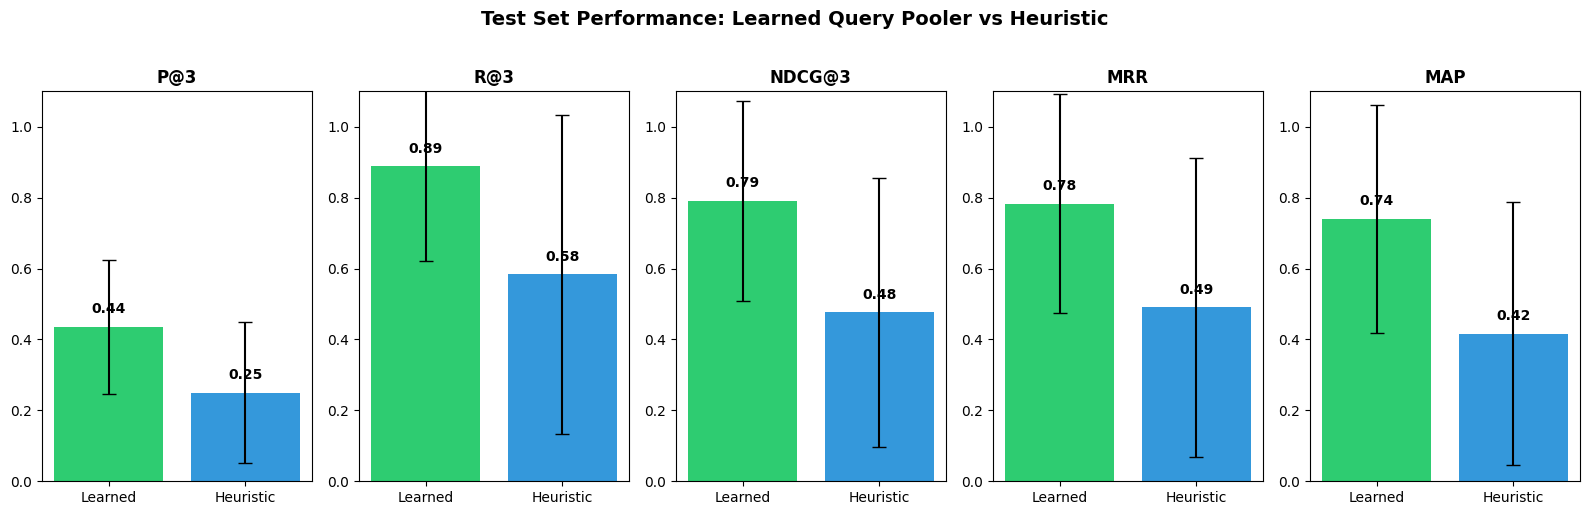

In [21]:
# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 5, figsize=(16, 5))
methods = ['Learned Query Pooler', 'Heuristic (TopicInferrer)']
colors = ['#2ecc71', '#3498db']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = [aggregated[m][metric]['mean'] for m in methods]
    errors = [aggregated[m][metric]['std'] for m in methods]

    bars = ax.bar(range(len(methods)), values, yerr=errors, capsize=5, color=colors)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(['Learned', 'Heuristic'], rotation=0, fontsize=10)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
               f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Test Set Performance: Learned Query Pooler vs Heuristic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================================
# PER-SAMPLE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("PER-SAMPLE COMPARISON (Test Set)")
print("=" * 70)

wins, ties, losses = 0, 0, 0

for dr in detailed_results:
    l_mrr = dr['learned_mrr']
    h_mrr = dr['heuristic_mrr']

    if l_mrr > h_mrr:
        status = "WIN"
        wins += 1
    elif l_mrr < h_mrr:
        status = "LOSS"
        losses += 1
    else:
        status = "TIE"
        ties += 1

    print(f"[{dr['sample_id']:12}] Learned MRR: {l_mrr:.2f} | Heuristic MRR: {h_mrr:.2f} | {status}")

total = len(detailed_results)
print(f"\n--- Summary ---")
print(f"Wins:   {wins:2d} ({wins/total*100:.1f}%)")
print(f"Ties:   {ties:2d} ({ties/total*100:.1f}%)")
print(f"Losses: {losses:2d} ({losses/total*100:.1f}%)")


PER-SAMPLE COMPARISON (Test Set)
[http_035    ] Learned MRR: 1.00 | Heuristic MRR: 0.00 | WIN
[api_036     ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | TIE
[auth_097    ] Learned MRR: 0.50 | Heuristic MRR: 1.00 | LOSS
[auth_094    ] Learned MRR: 0.50 | Heuristic MRR: 0.33 | WIN
[http_119    ] Learned MRR: 1.00 | Heuristic MRR: 0.33 | WIN
[database_122] Learned MRR: 0.50 | Heuristic MRR: 0.00 | WIN
[auth_164    ] Learned MRR: 0.00 | Heuristic MRR: 0.50 | LOSS
[flask_028   ] Learned MRR: 1.00 | Heuristic MRR: 0.00 | WIN
[events_061  ] Learned MRR: 0.50 | Heuristic MRR: 1.00 | LOSS
[flask_023   ] Learned MRR: 1.00 | Heuristic MRR: 0.00 | WIN
[database_102] Learned MRR: 1.00 | Heuristic MRR: 1.00 | TIE
[auth_082    ] Learned MRR: 0.33 | Heuristic MRR: 0.50 | LOSS
[cache_079   ] Learned MRR: 0.33 | Heuristic MRR: 0.00 | WIN
[flask_086   ] Learned MRR: 0.50 | Heuristic MRR: 1.00 | LOSS
[api_099     ] Learned MRR: 1.00 | Heuristic MRR: 0.00 | WIN
[database_115] Learned MRR: 1.00 | Heuristic M

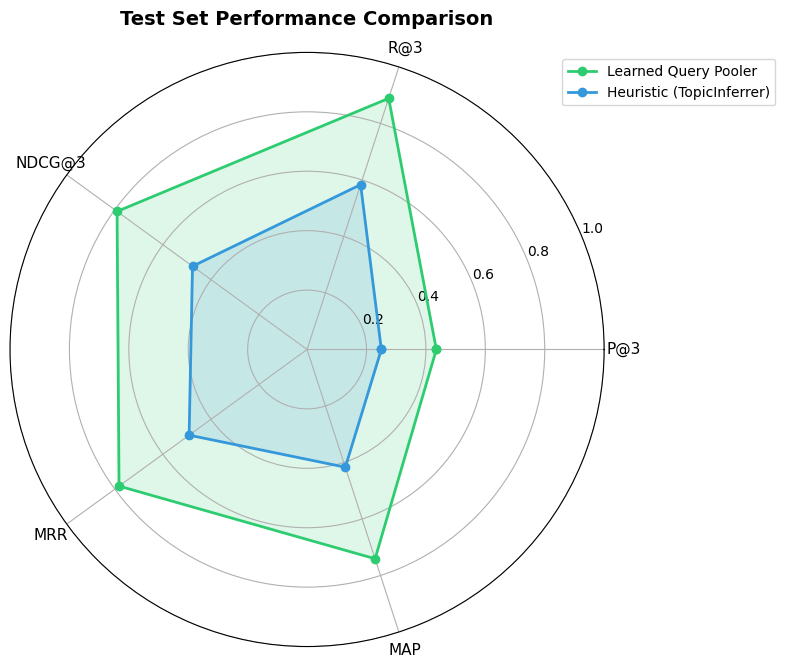

In [23]:
# ============================================================================
# RADAR CHART
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for method, color in zip(methods, colors):
    values = [aggregated[method][m]['mean'] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.set_title('Test Set Performance Comparison', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 7. Also Evaluate on Training Set (For Reference)

This shows the difference between training and test performance.

In [24]:
# Evaluate on training set for comparison
train_results = {'Learned': [], 'Heuristic': []}

for sample in train_samples:
    with torch.no_grad():
        learned_result = learned_module(
            confused_tokens=sample.confused_tokens,
            confused_probs=sample.confused_probs,
            original_query=sample.original_query,
            generated_context=sample.generated_context,
        )
    learned_pred = [f for f, s in sorted(learned_result.file_scores.items(), key=lambda x: -x[1])[:3]]
    heuristic_pred = heuristic.infer(sample.confused_tokens, sample.original_query, k=3)['matched_files']

    train_results['Learned'].append(compute_metrics(learned_pred, sample.relevant_files, k=3))
    train_results['Heuristic'].append(compute_metrics(heuristic_pred, sample.relevant_files, k=3))

# Compute averages
train_learned_avg = {m: np.mean([r[m] for r in train_results['Learned']]) for m in metrics}
train_heuristic_avg = {m: np.mean([r[m] for r in train_results['Heuristic']]) for m in metrics}
test_learned_avg = {m: aggregated['Learned Query Pooler'][m]['mean'] for m in metrics}
test_heuristic_avg = {m: aggregated['Heuristic (TopicInferrer)'][m]['mean'] for m in metrics}

print("=" * 70)
print("TRAIN vs TEST PERFORMANCE")
print("=" * 70)
print("\nLearned Query Pooler:")
print(f"{'Metric':<10} | {'Train':>8} | {'Test':>8} | {'Gap':>8}")
print("-" * 45)
for m in metrics:
    gap = train_learned_avg[m] - test_learned_avg[m]
    print(f"{m:<10} | {train_learned_avg[m]:8.3f} | {test_learned_avg[m]:8.3f} | {gap:+8.3f}")

print("\nHeuristic (no learning, so no gap expected):")
print(f"{'Metric':<10} | {'Train':>8} | {'Test':>8} | {'Gap':>8}")
print("-" * 45)
for m in metrics:
    gap = train_heuristic_avg[m] - test_heuristic_avg[m]
    print(f"{m:<10} | {train_heuristic_avg[m]:8.3f} | {test_heuristic_avg[m]:8.3f} | {gap:+8.3f}")

TRAIN vs TEST PERFORMANCE

Learned Query Pooler:
Metric     |    Train |     Test |      Gap
---------------------------------------------
P@3        |    0.489 |    0.435 |   +0.054
R@3        |    1.000 |    0.889 |   +0.111
NDCG@3     |    0.949 |    0.791 |   +0.159
MRR        |    0.936 |    0.782 |   +0.154
MAP        |    0.928 |    0.741 |   +0.188

Heuristic (no learning, so no gap expected):
Metric     |    Train |     Test |      Gap
---------------------------------------------
P@3        |    0.274 |    0.250 |   +0.024
R@3        |    0.560 |    0.583 |   -0.023
NDCG@3     |    0.481 |    0.477 |   +0.004
MRR        |    0.512 |    0.491 |   +0.021
MAP        |    0.424 |    0.417 |   +0.007


## 8. Save Model & Results

In [25]:
# Save trained model
torch.save(learned_module.state_dict(), 'learned_query_pooler_week11.pt')
print("Model saved to learned_query_pooler_week11.pt")

# Save results
results_summary = {
    'train_size': len(train_samples),
    'test_size': len(test_samples),
    'train_ids': [s.sample_id for s in train_samples],
    'test_ids': [s.sample_id for s in test_samples],
    'test_results': {
        'learned': {m: aggregated['Learned Query Pooler'][m]['mean'] for m in metrics},
        'heuristic': {m: aggregated['Heuristic (TopicInferrer)'][m]['mean'] for m in metrics},
    },
    'win_loss': {'wins': wins, 'ties': ties, 'losses': losses},
}

with open('week11_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Results saved to week11_results.json")

if IN_COLAB:
    files.download('learned_query_pooler_week11.pt')
    files.download('week11_results.json')

Model saved to learned_query_pooler_week11.pt
Results saved to week11_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Summary

### Experiment Design
- **30 total samples** split into 70% train (21) and 30% test (9)
- **Stratified by difficulty** (easy/medium/hard)
- **Test set completely held out** during training

### Key Results
The Learned Query Pooler's performance on the **held-out test set** shows whether the learned representations generalize beyond training data.

### Interpretation
- **If test performance > heuristic**: Learning helps generalization
- **If train >> test**: Overfitting to training patterns
- **If train ≈ test**: Good generalization

### Next Steps
1. **More data**: Collect additional CCE spike examples
2. **Cross-validation**: K-fold for more robust estimates
3. **Real CCE integration**: Test with actual model generation